# Evaluate nuclear scattering NREFT_rates
The nuclear responses implemented in RAPIDD are:
  - Fitz: evaluated using DMFormFactorV6 ([Fitzpatrick et al.](https://www.ocf.berkeley.edu/~nanand/software/dmformfactor/))
  - GCN: evaluated using DMFormFactorV6 using the one-body density matrices (OBDM) computed employing a GCN5082 nuclear shell model. The OBDM were taken from [this repository](https://github.com/Berkeley-Electroweak-Physics/Elastic/tree/main).
  - SN: evaluated with the SN100PN nuclear shell model, taken from this [supplementary material article](https://journals.aps.org/prd/supplemental/10.1103/PhysRevD.109.075036/Supplementary.pdf).

## Evaluate the NREFT NREFT_rates
Calculate the nuclear recoil NREFT_rates setting the non-relativistic EFT (NREFT) coefficients.
\begin{align}
\mathcal{O}_1 &= \mathbf{1}_\chi \mathbf{1}_N; &
\mathcal{O}_9 &= i\mathbf{S}_\chi \cdot \left(\mathbf{S}_N \times \frac{\mathbf{q}}{m_N}\right); \\
\mathcal{O}_3 &= i\mathbf{S}_N \cdot \left(\frac{\mathbf{q}}{m_N} \times \mathbf{v}^\perp\right); &
\mathcal{O}_{10} &= i\mathbf{S}_N \cdot \left(\frac{\mathbf{q}}{m_N}\right); \\
\mathcal{O}_4 &= \mathbf{S}_\chi \cdot \mathbf{S}_N; &
\mathcal{O}_{11} &= i\mathbf{S}_\chi \cdot \left(\frac{\mathbf{q}}{m_N}\right); \\
\mathcal{O}_5 &= i\mathbf{S}_\chi \cdot \left(\frac{\mathbf{q}}{m_N} \times \mathbf{v}^\perp\right); &
\mathcal{O}_{12} &= \mathbf{S}_\chi \cdot \left(\mathbf{S}_N \times \mathbf{v}^\perp\right) \\
\mathcal{O}_6 &= \left(\mathbf{S}_\chi \cdot \frac{\mathbf{q}}{m_N}\right)\left(\mathbf{S}_N \cdot \frac{\mathbf{q}}{m_N}\right); &
\mathcal{O}_{13} &= i\left(\mathbf{S}_\chi \cdot \mathbf{v}^\perp\right)\left(\mathbf{S}_N \cdot \frac{\mathbf{q}}{m_N}\right); \\
\mathcal{O}_7 &= \mathbf{S}_N \cdot \mathbf{v}^\perp; &
\mathcal{O}_{14} &= i\left(\mathbf{S}_\chi \cdot \frac{\mathbf{q}}{m_N}\right)\left(\mathbf{S}_N \cdot \mathbf{v}^\perp\right); \\
\mathcal{O}_8 &= \mathbf{S}_\chi \cdot \mathbf{v}^\perp; &
\mathcal{O}_{15} &= -\left(\mathbf{S}_\chi \cdot \frac{\mathbf{q}}{m_N}\right)\left[\left(\mathbf{S}_N \times \mathbf{v}^\perp\right) \cdot \frac{\mathbf{q}}{m_N}\right].
\end{align}

In [1]:
import numpy as np
import rapidd
import matplotlib.pyplot as plt

In [2]:
# Global variables
target = 'Xe'  # Target element
nuclear_models = ['iso_Fitz', 'iso_GCN5082', 'pn_SN100PN']
m_chi = 200  # GeV, WIMP mass
rhoDM = 0.3  # GeV/cm^3, local DM density
nE = 100 # number of energy points
E_min = 0.1 # keV, minimum recoil energy
E_max = 100 # keV, maximum recoil energy
energies_NREFT = np.logspace(np.log10(E_min), np.log10(E_max), nE)

# Couplings to nucleons. Dimensionless as they are normalized to the higgs vev^2.
c_prot = 1.0 # coupling to protons
c_neut = 1.0 # coupling to neutrons

# NREFT operators from O_1 to O_15, excluding O_2
NREFT_coeffs_list = [i for i in range(1, 16) if i != 2]

In [3]:
NREFT_rates = {}
rapidd.read_halo('../lib/halo_table/halo_table_SHM.dat')

for i in NREFT_coeffs_list:
    NREFT_rates[i] = {}
    rapidd.reset_coefficients()
    rapidd.set_any_Ncoeff(c_prot, i, 'p')
    rapidd.set_any_Ncoeff(c_neut, i, 'n')
    for nucl_mod in nuclear_models:
        NREFT_rates[i][nucl_mod] = np.array([
                            rapidd.difrate_dER(
                            rhoDM=rhoDM, mDM=m_chi, ER=E,
                            model='SHM', target=target, basis=nucl_mod)
                            for E in energies_NREFT])

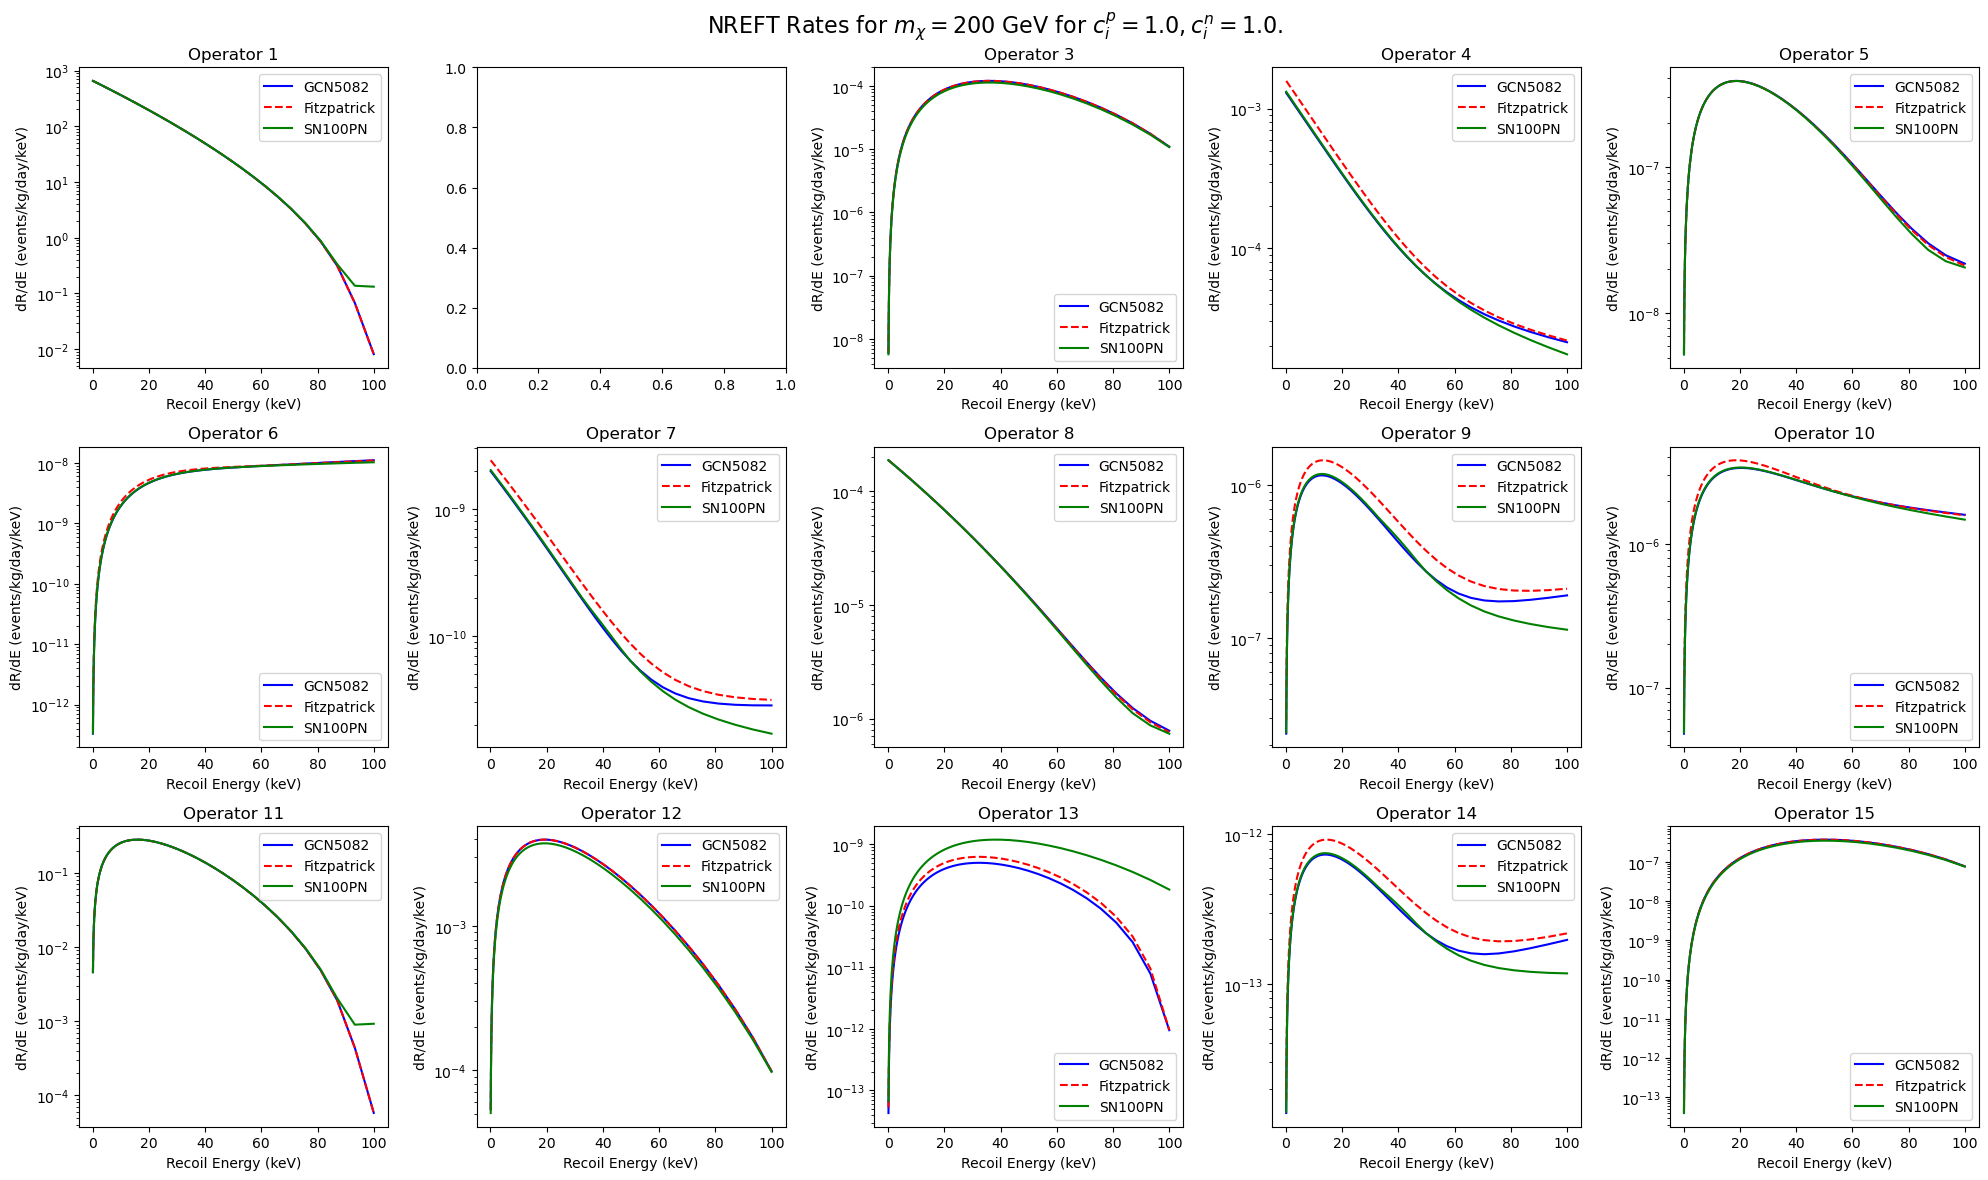

In [4]:
# plot all the NREFT_rates
fig, axes = plt.subplots(3, 5, figsize=(20, 12))
axes = axes.flatten()

for i in NREFT_coeffs_list:      
    axes[i-1].plot(energies_NREFT, NREFT_rates[i]['iso_GCN5082'], label='GCN5082', color='blue')
    axes[i-1].plot(energies_NREFT, NREFT_rates[i]['iso_Fitz'], label='Fitzpatrick', color='red', ls='--')
    axes[i-1].plot(energies_NREFT, NREFT_rates[i]['pn_SN100PN'], label='SN100PN', color='green')
    axes[i-1].set_xlabel('Recoil Energy (keV)')
    axes[i-1].set_ylabel('dR/dE (events/kg/day/keV)')
    axes[i-1].set_title(f'Operator {i}')
    axes[i-1].set_yscale('log')
    axes[i-1].legend()

plt.suptitle(f'NREFT Rates for $m_\\chi = {m_chi}$ GeV for $c^p_i = {c_prot},  c^n_i = {c_neut}$.', fontsize=16)
plt.tight_layout()
plt.show()

## Evaluate the EFT NREFT_rates
Set the EFT coefficients from Table 1 of https://arxiv.org/pdf/1308.6288
| $j$ | $\mathcal{L}^j_\text{int}$ | Nonrelativistic Reduction | $\sum_i c_i \mathcal{O}_i$ |
|:--:|:--|:--|:--|
| 1 | $\bar{\chi}\chi\bar{N}N$ | $1_\chi 1_N$ | $\mathcal{O}_1$ |
| 2 | $i\bar{\chi}\chi\bar{N}\gamma^5 N$ | $i\dfrac{\vec{q}}{m_N}\cdot\vec{S}_N$ | $\mathcal{O}_{10}$ |
| 3 | $i\bar{\chi}\gamma^5\chi\bar{N}N$ | $-i\dfrac{\vec{q}}{m_\chi}\cdot\vec{S}_\chi$ | $-\dfrac{m_N}{m_\chi}\mathcal{O}_{11}$ |
| 4 | $\bar{\chi}\gamma^5\chi\bar{N}\gamma^5 N$ | $-\dfrac{\vec{q}}{m_\chi}\cdot\vec{S}_\chi\ \dfrac{\vec{q}}{m_N}\cdot\vec{S}_N$ | $-\dfrac{m_N}{m_\chi}\mathcal{O}_6$ |
| 5 | $\dfrac{P^\mu}{m_\mathrm{M}}\bar{\chi}\chi\dfrac{K_\mu}{m_\mathrm{M}}\bar{N}N$ | $4\dfrac{m_\chi m_N}{m_\mathrm{M}^2}1_\chi 1_N$ | $4\dfrac{m_\chi m_N}{m_\mathrm{M}^2}\mathcal{O}_1$ |
| 6 | $\dfrac{P^\mu}{m_\mathrm{M}}\bar{\chi}\chi\bar{N}i\sigma_{\mu\alpha}\dfrac{q^\alpha}{m_\mathrm{M}}N$ | $-\dfrac{m_\chi}{m_N}\dfrac{\vec{q}^{\,2}}{m_\mathrm{M}^2}1_\chi 1_N -4i\dfrac{m_\chi}{m_\mathrm{M}}\vec{v}^\perp\cdot\left(\dfrac{\vec{q}}{m_\mathrm{M}}\times\vec{S}_N\right)$ | $-\dfrac{m_\chi}{m_N}\dfrac{\vec{q}^{\,2}}{m_\mathrm{M}^2}\mathcal{O}_1 +4\dfrac{m_\chi m_N}{m_\mathrm{M}^2}\mathcal{O}_3$ |
| 7 | $\dfrac{P^\mu}{m_\mathrm{M}}\bar{\chi}\chi\bar{N}\gamma_\mu\gamma^5 N$ | $-4\dfrac{m_\chi}{m_\mathrm{M}}\vec{v}^\perp\cdot\vec{S}_N$ | $-4\dfrac{m_\chi}{m_\mathrm{M}}\mathcal{O}_7$ |
| 8 | $i\dfrac{P^\mu}{m_\mathrm{M}}\bar{\chi}\chi\dfrac{K_\mu}{m_\mathrm{M}}\bar{N}\gamma^5 N$ | $4i\dfrac{m_\chi}{m_\mathrm{M}}\dfrac{\vec{q}}{m_\mathrm{M}}\cdot\vec{S}_N$ | $4\dfrac{m_\chi m_N}{m_\mathrm{M}^2}\mathcal{O}_{10}$ |
| 9 | $\bar{\chi}i\sigma^{\mu\nu}\dfrac{q_\nu}{m_\mathrm{M}}\chi\dfrac{K_\mu}{m_\mathrm{M}}\bar{N}N$ | $\dfrac{m_N}{m_\chi}\dfrac{\vec{q}^{\,2}}{m_\mathrm{M}^2}1_\chi 1_N +4i\dfrac{m_N}{m_\mathrm{M}}\vec{v}^\perp\cdot\left(\dfrac{\vec{q}}{m_\mathrm{M}}\times\vec{S}_\chi\right)$ | $\dfrac{m_N}{m_\chi}\dfrac{\vec{q}^{\,2}}{m_\mathrm{M}^2}\mathcal{O}_1 -4\dfrac{m_N^2}{m_\mathrm{M}^2}\mathcal{O}_5$ |
| 10 | $\bar{\chi}i\sigma^{\mu\nu}\dfrac{q_\nu}{m_\mathrm{M}}\chi\bar{N}i\sigma_{\mu\alpha}\dfrac{q^\alpha}{m_\mathrm{M}}N$ | $4\left(\dfrac{\vec{q}}{m_\mathrm{M}}\times\vec{S}_\chi\right)\cdot\left(\dfrac{\vec{q}}{m_\mathrm{M}}\times\vec{S}_N\right)$ | $4\left(\dfrac{\vec{q}^{\,2}}{m_\mathrm{M}^2}\mathcal{O}_4 -\dfrac{m_N^2}{m_\mathrm{M}^2}\mathcal{O}_6\right)$ |
| 11 | $\bar{\chi}i\sigma^{\mu\nu}\dfrac{q_\nu}{m_\mathrm{M}}\chi\bar{N}\gamma^\mu\gamma^5 N$ | $-4i\left(\dfrac{\vec{q}}{m_\mathrm{M}}\times\vec{S}_\chi\right)\cdot\vec{S}_N$ | $-4\dfrac{m_N}{m_\mathrm{M}}\mathcal{O}_9$ |
| 12 | $i\bar{\chi}i\sigma^{\mu\nu}\dfrac{q_\nu}{m_\mathrm{M}}\chi\dfrac{K_\mu}{m_\mathrm{M}}\bar{N}\gamma^5 N$ | $\left[i\dfrac{\vec{q}^{\,2}}{m_\chi m_\mathrm{M}} -4\vec{v}^\perp\cdot\left(\dfrac{\vec{q}}{m_\mathrm{M}}\times\vec{S}_\chi\right)\right]\dfrac{\vec{q}}{m_\mathrm{M}}\cdot\vec{S}_N$ | $\dfrac{m_N}{m_\chi}\dfrac{\vec{q}^{\,2}}{m_\mathrm{M}^2}\mathcal{O}_{10} +4\dfrac{\vec{q}^{\,2}}{m_\mathrm{M}^2}\mathcal{O}_{12} +4\dfrac{m_N^2}{m_\mathrm{M}^2}\mathcal{O}_{15}$ |
| 13 | $\bar{\chi}\gamma^\mu\gamma^5\chi\dfrac{K_\mu}{m_\mathrm{M}}\bar{N}N$ | $4\dfrac{m_N}{m_\mathrm{M}}\vec{v}^\perp\cdot\vec{S}_\chi$ | $4\dfrac{m_N}{m_\mathrm{M}}\mathcal{O}_8$ |
| 14 | $\bar{\chi}\gamma^\mu\gamma^5\chi\bar{N}i\sigma_{\mu\alpha}\dfrac{q^\alpha}{m_\mathrm{M}}N$ | $-4i\vec{S}_\chi\cdot\left(\dfrac{\vec{q}}{m_\mathrm{M}}\times\vec{S}_N\right)$ | $4\dfrac{m_N}{m_\mathrm{M}}\mathcal{O}_9$ |
| 15 | $\bar{\chi}\gamma^\mu\gamma^5\chi\bar{N}\gamma^\mu\gamma^5 N$ | $-4\vec{S}_\chi\cdot\vec{S}_N$ | $-4\mathcal{O}_4$ |
| 16 | $i\bar{\chi}\gamma^\mu\gamma^5\chi\dfrac{K^\mu}{m_\mathrm{M}}\bar{N}\gamma^5 N$ | $4i\vec{v}^\perp\cdot\vec{S}_\chi\ \dfrac{\vec{q}}{m_\mathrm{M}}\cdot\vec{S}_N$ | $4\dfrac{m_N}{m_\mathrm{M}}\mathcal{O}_{13}$ |
| 17 | $i\dfrac{P^\mu}{m_\mathrm{M}}\bar{\chi}\gamma^5\chi\dfrac{K_\mu}{m_\mathrm{M}}\bar{N}N$ | $-4i\dfrac{m_N}{m_\mathrm{M}}\dfrac{\vec{q}}{m_\mathrm{M}}\cdot\vec{S}_\chi$ | $-4\dfrac{m_N^2}{m_\mathrm{M}^2}\mathcal{O}_{11}$ |
| 18 | $i\dfrac{P^\mu}{m_\mathrm{M}}\bar{\chi}\gamma^5\chi\bar{N}i\sigma_{\mu\alpha}\dfrac{q^\alpha}{m_\mathrm{M}}N$ | $\dfrac{\vec{q}}{m_\mathrm{M}}\cdot\vec{S}_\chi\left[i\dfrac{\vec{q}^{\,2}}{m_N m_\mathrm{M}} -4\vec{v}^\perp\cdot\left(\dfrac{\vec{q}}{m_\mathrm{M}}\times\vec{S}_N\right)\right]$ | $\dfrac{\vec{q}^{\,2}}{m_\mathrm{M}^2}\mathcal{O}_{11} +4\dfrac{m_N^2}{m_\mathrm{M}^2}\mathcal{O}_{15}$ |
| 19 | $i\dfrac{P^\mu}{m_\mathrm{M}}\bar{\chi}\gamma^5\chi\bar{N}\gamma_\mu\gamma^5 N$ | $4i\dfrac{\vec{q}}{m_\mathrm{M}}\cdot\vec{S}_\chi\ \vec{v}_\perp\cdot\vec{S}_N$ | $4\dfrac{m_N}{m_\mathrm{M}}\mathcal{O}_{14}$ |
| 20 | $\dfrac{P^\mu}{m_\mathrm{M}}\bar{\chi}\gamma^5\chi\dfrac{K_\mu}{m_\mathrm{M}}\bar{N}\gamma^5 N$ | $-4\dfrac{\vec{q}}{m_\mathrm{M}}\cdot\vec{S}_\chi\ \dfrac{\vec{q}}{m_\mathrm{M}}\cdot\vec{S}_N$ | $-4\dfrac{m_N^2}{m_\mathrm{M}^2}\mathcal{O}_6$ |

In [5]:
EFT_coeffs_list = [i for i in range(1, 21)]
m_M = 1 # GeV, mediator mass
nE = 100 # number of energy points
E_min = 0.1 # keV, minimum recoil energy
E_max = 100 # keV, maximum recoil energy
energies_EFT = np.logspace(np.log10(E_min), np.log10(E_max), nE)

In [6]:
EFT_rates = {}
rapidd.read_halo('../lib/halo_table/halo_table_SHM.dat')

for i in EFT_coeffs_list:
    rapidd.reset_coefficients()
    EFT_rates[i] = {}
    for nucl_mod in nuclear_models:
        EFT_rates[i][nucl_mod] = np.zeros(nE)
        for i_E, E in enumerate(energies_EFT):
            rapidd.set_any_N_EFT_coeff(i, m_chi, m_M, target, E, 'p', c=1)
            rapidd.set_any_N_EFT_coeff(i, m_chi, m_M, target, E, 'n', c=1)
            EFT_rates[i][nucl_mod][i_E] = rapidd.difrate_dER(rhoDM=rhoDM, mDM=m_chi,
                                                             ER=E, model='SHM',
                                                             target=target, basis=nucl_mod)

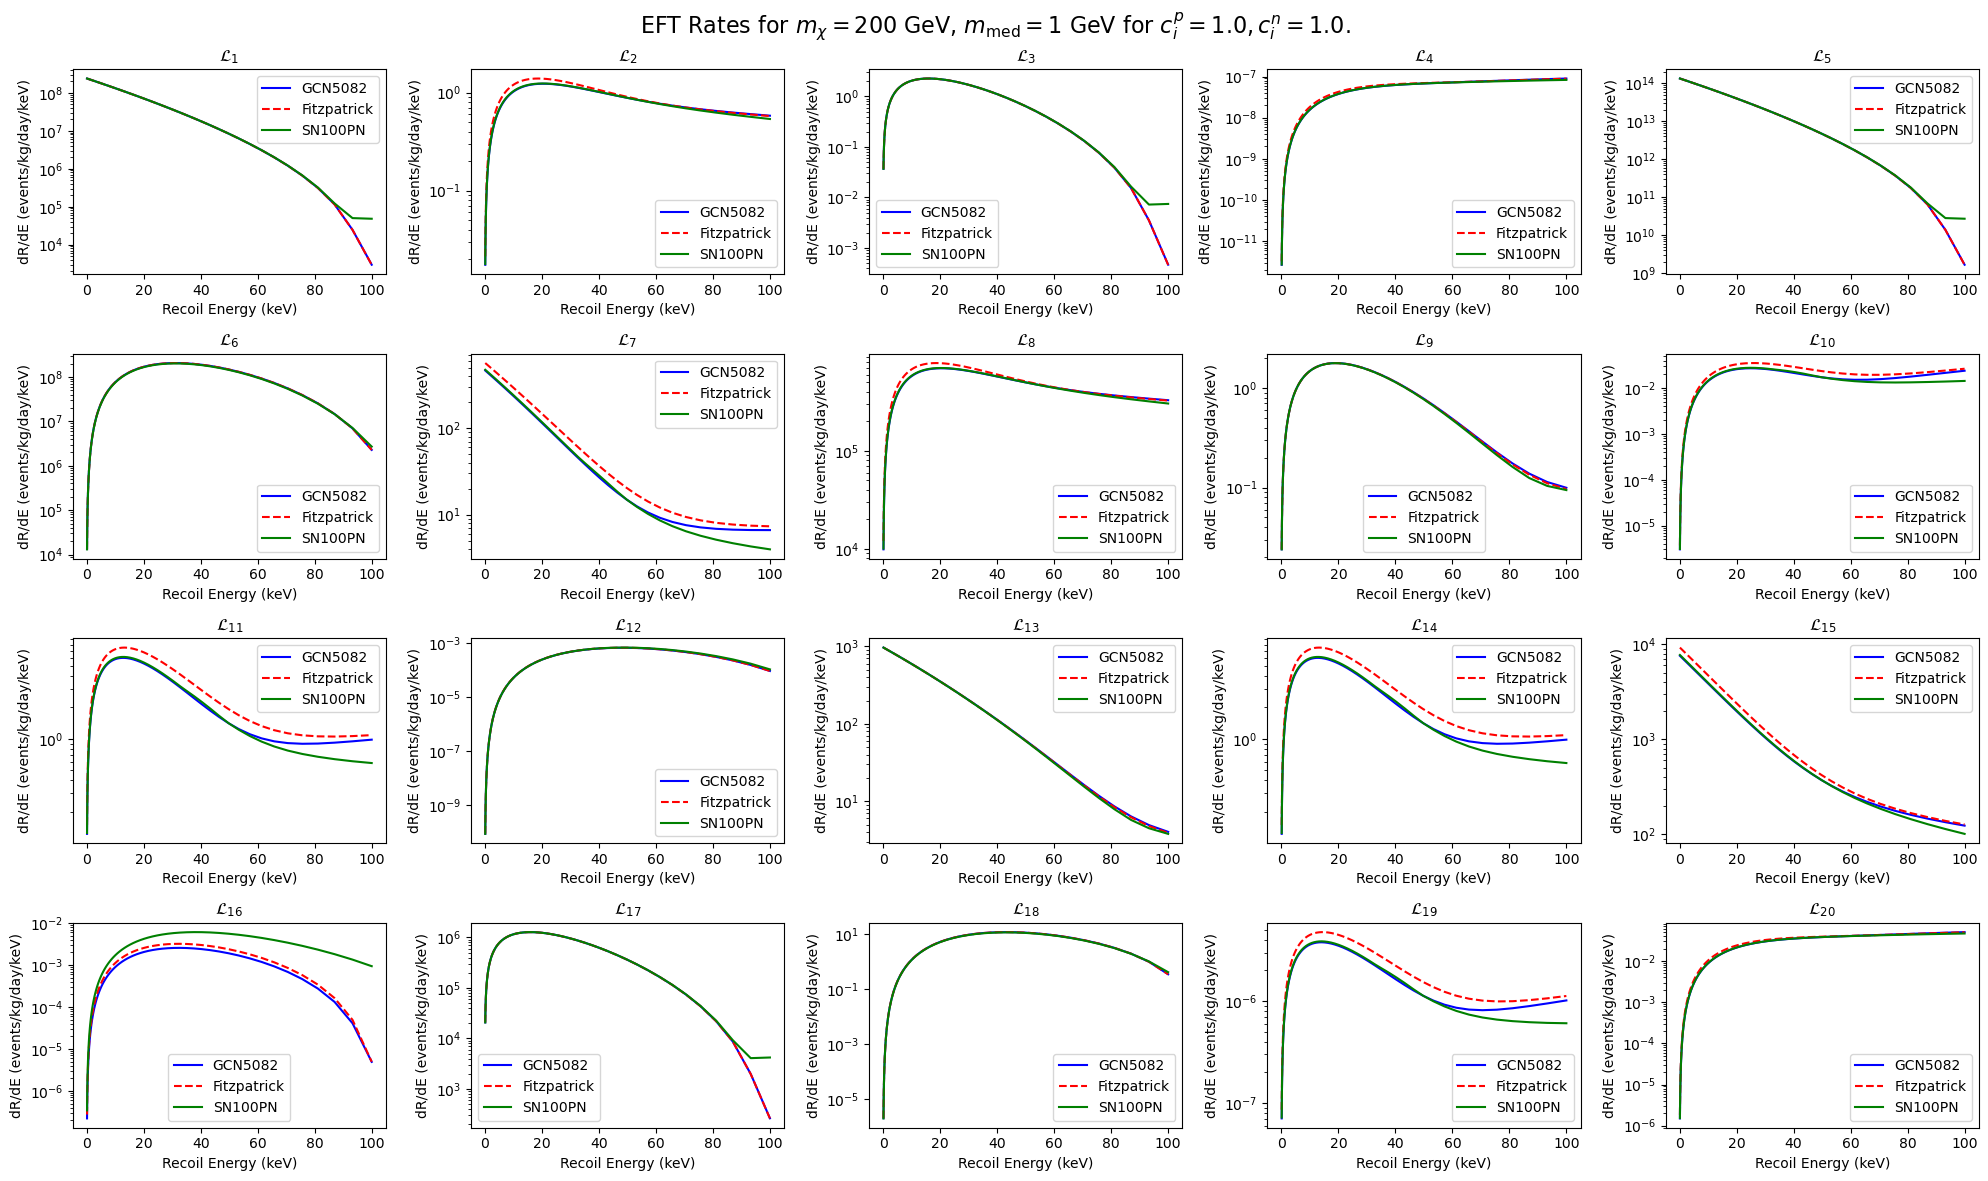

In [7]:
# plot all the EFT_rates
fig, axes = plt.subplots(4, 5, figsize=(20, 12))
axes = axes.flatten()

for i in EFT_coeffs_list:      
    axes[i-1].plot(energies_EFT, EFT_rates[i]['iso_GCN5082']*1000*365, label='GCN5082', color='blue')
    axes[i-1].plot(energies_EFT, EFT_rates[i]['iso_Fitz']*1000*365, label='Fitzpatrick', color='red', ls='--')
    axes[i-1].plot(energies_EFT, EFT_rates[i]['pn_SN100PN']*1000*365, label='SN100PN', color='green')
    axes[i-1].set_xlabel('Recoil Energy (keV)')
    axes[i-1].set_ylabel('dR/dE (events/kg/day/keV)')
    axes[i-1].set_title(f'$\\mathcal{{L}}_{{{i}}}$')
    axes[i-1].set_yscale('log')
    axes[i-1].legend()

plt.suptitle(f'EFT Rates for $m_\\chi = {m_chi}$ GeV, $m_\\text{{med}} = {m_M}$ GeV for $c^p_i = {c_prot},  c^n_i = {c_neut}$.', fontsize=16)
plt.tight_layout()
plt.show()

## Inelastic DM
Compute the inelastic scattering for different values of the mass splitting $\delta$.

We use different halo models: the Standard Halo Model (SHM) and the SHM considering the Large Magellanic Cloud (LMC) contribution, as done [here](https://arxiv.org/pdf/2609.04175v1).

In [8]:
deltas = [0,100,200,300] # keV
iDM_NREFT_list = [1,4] # smaller list, but one can compute iDM rates for all operators
nucl_mod = 'iso_GCN5082' # selecting just one

In [9]:
halo_profiles = ['SHM', 'SHM_wLMC', 'Lisanti']

# halos already calculated in RAPIDD_for_DM/lib/halo_table.
# Calculate them again if you want to change the parameters in the halo model.
do_calculate_halo = False
if do_calculate_halo:
    for profile in halo_profiles:
        table_path = f'../lib/halo_table/halo_table_{profile}.dat'
        rapidd.calc_halo(table_path, profile=profile, vesc=544, v0=238., beta=0.,  
                    v0_lsr=238., v_pec=(11.1, 12.2, 7.3), k_lisanti=1.5, i=2,
                    t0=151., T=None, w=0.006, vb=570., cosb=-0.71, sigb=100., vcut=200.)

In [10]:
# what are all those halo parameters?
rapidd.calc_halo?

Signature:
rapidd.calc_halo(
    table_path,
    profile='SHM',
    vesc=544,
    v0=238.0,
    beta=0.0,
    v0_lsr=238.0,
    v_pec=(11.1, 12.2, 7.3),
    k_lisanti=1.5,
    i=2,
    t0=151.0,
    T=None,
    w=0.006,
    vb=570.0,
    cosb=-0.71,
    sigb=100.0,
    vcut=200.0,
)
Docstring:
Compute the dark matter halo velocity-integral table and write it to disk
(calls define_and_write_halo if T is None, define_and_write_halo_time
otherwise).

Parameters
----------
table_path : str
    Destination path for the output table.
profile : {"SHM", "SHM_beta", "SHM_wLMC", "Lisanti"}
    Halo velocity-distribution model.
vesc : float
    Galactic escape velocity [km/s].
v0 : float
    Velocity-dispersion parameter of the halo distribution [km/s].
beta : float
    Smooth-cutoff parameter, used only by profile="SHM_beta".
v0_lsr : float
    Local Standard of Rest circular speed around the Galactic center
    [km/s]. Used only to build the Sun/Earth velocity relative to the
    halo rest fram

In [11]:
iDM_rates = {}

for i in iDM_NREFT_list:
    iDM_rates[i] = {}
    rapidd.reset_coefficients()
    rapidd.set_any_Ncoeff(c_prot, i, 'p')
    rapidd.set_any_Ncoeff(c_neut, i, 'n')
    for halo in halo_profiles:
        iDM_rates[i][halo] = {}
        rapidd.read_halo(f'../lib/halo_table/halo_table_{halo}.dat')
        for delta in deltas:
            iDM_rates[i][halo][delta] = np.array([
                                        rapidd.difrate_dER(
                                        rhoDM=rhoDM, mDM=m_chi, ER=E,
                                        model='SHM', target=target,
                                        basis=nucl_mod, delta=delta)
                                        for E in energies_NREFT])

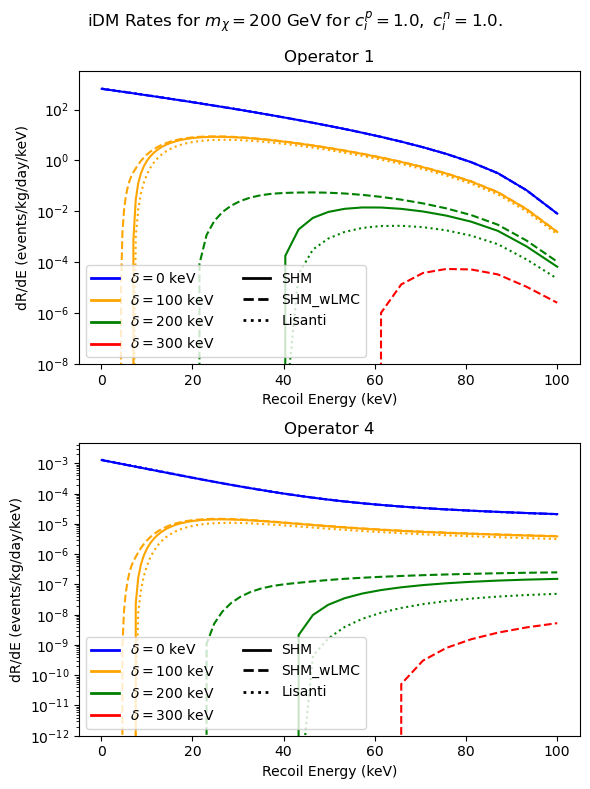

In [15]:
# One subplot per operator; halos overlaid (solid = SHM, dashed = SHM+LMC)
halo_styles = {halo_profiles[0]: '-', halo_profiles[1]: '--', halo_profiles[2]: ':'}
colors = ['blue', 'orange', 'green', 'red']

fig, axes = plt.subplots(2, 1, figsize=(6, 8))
axes = axes.flatten()

# create a legend for the deltas and halos
from matplotlib.lines import Line2D
delta_lines = [Line2D([0], [0], color=colors[k], lw=2, label=f'$\\delta = {delta}$ keV') for k, delta in enumerate(deltas)]
halo_lines = [Line2D([0], [0], color='black', lw=2, ls=halo_styles[halo], label=halo)
              for halo in halo_profiles]

for i, op in enumerate(iDM_NREFT_list):
    ax = axes[i]
    for k, delta in enumerate(deltas):
        for halo in halo_profiles:
            ax.plot(energies_NREFT, iDM_rates[op][halo][delta],
                    color=colors[k], ls=halo_styles[halo])
    ax.set_xlabel('Recoil Energy (keV)')
    ax.set_ylabel('dR/dE (events/kg/day/keV)')
    ax.set_title(f'Operator {op}')
    ax.set_yscale('log')
    ax.legend(handles=delta_lines + halo_lines, loc='lower left', frameon=True, ncol=2)

axes[0].set_ylim(bottom=1e-8)
axes[1].set_ylim(bottom=1e-12)
plt.suptitle(f'iDM Rates for $m_\\chi = {m_chi}$ GeV for $c^p_i = {c_prot},\\ c^n_i = {c_neut}$.')
plt.tight_layout()
plt.show()